Scraping

In [ ]:
!pip install google-play-scraper
!pip install pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from google_play_scraper import reviews, Sort
from tqdm import tqdm

In [ ]:
apps = {
    "LinkedIn": "com.linkedin.android",
    "JobStreet": "com.jobstreet.jobstreet",
    "Glints": "com.glints.candidate"
}

In [ ]:
TARGET_REVIEW = 6000

In [ ]:
from datetime import datetime

def scrape_reviews(app_id, app_name, start_date, end_date, count=2000):

    all_reviews = []
    continuation_token = None

    while len(all_reviews) < count:

        result, continuation_token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=200,
            continuation_token=continuation_token
        )

        if not result:
            break

        stop = False

        for r in result:

            review_date = r['at']

            # Lewati ulasan yang lebih baru dari end_date
            if review_date > end_date:
                continue

            # Berhenti jika sudah melewati start_date
            if review_date < start_date:
                stop = True
                break

            all_reviews.append({
                "app": app_name,
                "userName": r['userName'],
                "score": r['score'],
                "content": r['content'],
                "at": review_date.strftime("%Y-%m-%d %H:%M:%S")
            })

            if len(all_reviews) >= count:
                break

        print(f"{app_name}: {len(all_reviews)} data terkumpul")

        if stop or continuation_token is None:
            break

    return pd.DataFrame(all_reviews)

In [ ]:
from datetime import datetime

start_date = datetime(2025, 1, 1)
end_date = datetime(2026, 1, 1)

linkedin = scrape_reviews(
    "com.linkedin.android",
    "LinkedIn",
    start_date,
    end_date,
    count=2000
)

jobstreet = scrape_reviews(
    "com.jobstreet.jobstreet",
    "JobStreet",
    start_date,
    end_date,
    count=2000
)

glints = scrape_reviews(
    "com.glints.candidate",
    "Glints",
    start_date,
    end_date,
    count=2000
)

LinkedIn: 0 data terkumpul
LinkedIn: 0 data terkumpul
LinkedIn: 0 data terkumpul
LinkedIn: 0 data terkumpul
LinkedIn: 0 data terkumpul
LinkedIn: 0 data terkumpul
LinkedIn: 0 data terkumpul
LinkedIn: 54 data terkumpul
LinkedIn: 254 data terkumpul
LinkedIn: 454 data terkumpul
LinkedIn: 654 data terkumpul
LinkedIn: 854 data terkumpul
LinkedIn: 1054 data terkumpul
LinkedIn: 1254 data terkumpul
LinkedIn: 1454 data terkumpul
LinkedIn: 1654 data terkumpul
LinkedIn: 1854 data terkumpul
LinkedIn: 2000 data terkumpul
JobStreet: 0 data terkumpul
JobStreet: 0 data terkumpul
JobStreet: 0 data terkumpul
JobStreet: 0 data terkumpul
JobStreet: 0 data terkumpul
JobStreet: 0 data terkumpul
JobStreet: 47 data terkumpul
JobStreet: 247 data terkumpul
JobStreet: 447 data terkumpul
JobStreet: 647 data terkumpul
JobStreet: 847 data terkumpul
JobStreet: 1047 data terkumpul
JobStreet: 1247 data terkumpul
JobStreet: 1447 data terkumpul
JobStreet: 1647 data terkumpul
JobStreet: 1847 data terkumpul
JobStreet: 2000

In [ ]:
dataset = pd.concat(
    [linkedin, jobstreet, glints],
    ignore_index=True
)

print(dataset.head())
print(dataset.shape)

        app                          userName  score  \
0  LinkedIn                Idaman.depkolektor      1   
1  LinkedIn                M. Farizal Hamdani      5   
2  LinkedIn  Farrah Elfira Luthfionita Farras      1   
3  LinkedIn                             Aluna      5   
4  LinkedIn             DARFIN HIDAYAH SIAMIN      5   

                                             content                   at  
0  aplikasi sering ngebag, logout sendiri,aplikas...  2025-12-31 17:28:36  
1                                             Mantul  2025-12-31 14:02:06  
2  Mau login dipersulit. Masa tiba-tiba akun diba...  2025-12-31 08:40:44  
3  terimakasih, sangat membantu saya untuk membuk...  2025-12-31 02:06:19  
4                                                top  2025-12-31 00:22:49  
(6000, 5)


In [ ]:
dataset.to_excel("hasil_scraping_3_aplikasi.xlsx", index=False)

In [ ]:
dataset.head()

,app,userName,score,content,at
0,LinkedIn,Idaman.depkolektor,1,"aplikasi sering ngebag, logout sendiri,aplikas...",2025-12-31 17:28:36
1,LinkedIn,M. Farizal Hamdani,5,Mantul,2025-12-31 14:02:06
2,LinkedIn,Farrah Elfira Luthfionita Farras,1,Mau login dipersulit. Masa tiba-tiba akun diba...,2025-12-31 08:40:44
3,LinkedIn,Aluna,5,"terimakasih, sangat membantu saya untuk membuk...",2025-12-31 02:06:19
4,LinkedIn,DARFIN HIDAYAH SIAMIN,5,top,2025-12-31 00:22:49


Pre Prosesing

In [ ]:
!pip install Sastrawi nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_excel("hasil_scraping_3_aplikasi.xlsx")

print(df.shape)

df.head()

(6000, 5)


,app,userName,score,content,at
0,LinkedIn,Idaman.depkolektor,1,"aplikasi sering ngebag, logout sendiri,aplikas...",2025-12-31 17:28:36
1,LinkedIn,M. Farizal Hamdani,5,Mantul,2025-12-31 14:02:06
2,LinkedIn,Farrah Elfira Luthfionita Farras,1,Mau login dipersulit. Masa tiba-tiba akun diba...,2025-12-31 08:40:44
3,LinkedIn,Aluna,5,"terimakasih, sangat membantu saya untuk membuk...",2025-12-31 02:06:19
4,LinkedIn,DARFIN HIDAYAH SIAMIN,5,top,2025-12-31 00:22:49


In [ ]:
df = df.dropna(subset=["content"])

df = df[df["content"].str.strip() != ""]

print("Jumlah data :", len(df))

Jumlah data : 6000


In [ ]:
def case_folding(text):
    text = text.lower()
    return text

df["case_folding"] = df["content"].apply(case_folding)

df[["content","case_folding"]].head()

,content,case_folding
0,"aplikasi sering ngebag, logout sendiri,aplikas...","aplikasi sering ngebag, logout sendiri,aplikas..."
1,Mantul,mantul
2,Mau login dipersulit. Masa tiba-tiba akun diba...,mau login dipersulit. masa tiba-tiba akun diba...
3,"terimakasih, sangat membantu saya untuk membuk...","terimakasih, sangat membantu saya untuk membuk..."
4,top,top


In [ ]:
def cleaning(text):

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'www\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#\w+', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', ' ', text)

    text = re.sub(r'_', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["cleaning"] = df["case_folding"].apply(cleaning)

df[["case_folding","cleaning"]].head()

,case_folding,cleaning
0,"aplikasi sering ngebag, logout sendiri,aplikas...",aplikasi sering ngebag logout sendiri aplikasi...
1,mantul,mantul
2,mau login dipersulit. masa tiba-tiba akun diba...,mau login dipersulit masa tiba tiba akun dibat...
3,"terimakasih, sangat membantu saya untuk membuk...",terimakasih sangat membantu saya untuk membuka...
4,top,top


In [ ]:
nltk.download('punkt_tab')
df["tokenizing"] = df["cleaning"].apply(word_tokenize)

df[["cleaning","tokenizing"]].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,cleaning,tokenizing
0,aplikasi sering ngebag logout sendiri aplikasi...,"[aplikasi, sering, ngebag, logout, sendiri, ap..."
1,mantul,[mantul]
2,mau login dipersulit masa tiba tiba akun dibat...,"[mau, login, dipersulit, masa, tiba, tiba, aku..."
3,terimakasih sangat membantu saya untuk membuka...,"[terimakasih, sangat, membantu, saya, untuk, m..."
4,top,[top]


In [ ]:
stop_words = set(stopwords.words("indonesian"))

def stopword_removal(tokens):

    hasil = []

    for word in tokens:

        if word not in stop_words:

            hasil.append(word)

    return hasil

df["stopword"] = df["tokenizing"].apply(stopword_removal)

df[["tokenizing","stopword"]].head()

,tokenizing,stopword
0,"[aplikasi, sering, ngebag, logout, sendiri, ap...","[aplikasi, ngebag, logout, aplikasi, ga, logou..."
1,[mantul],[mantul]
2,"[mau, login, dipersulit, masa, tiba, tiba, aku...","[login, dipersulit, akun, dibatasi, gak, banget]"
3,"[terimakasih, sangat, membantu, saya, untuk, m...","[terimakasih, membantu, membuka, pengetahuan, ..."
4,[top],[top]


In [ ]:
factory = StemmerFactory()

stemmer = factory.create_stemmer()

def stemming(tokens):

    hasil = []

    for word in tokens:

        hasil.append(stemmer.stem(word))

    return hasil

df["stemming"] = df["stopword"].apply(stemming)

df[["stopword","stemming"]].head()

,stopword,stemming
0,"[aplikasi, ngebag, logout, aplikasi, ga, logou...","[aplikasi, ngebag, logout, aplikasi, ga, logou..."
1,[mantul],[mantul]
2,"[login, dipersulit, akun, dibatasi, gak, banget]","[login, sulit, akun, batas, gak, banget]"
3,"[terimakasih, membantu, membuka, pengetahuan, ...","[terimakasih, bantu, buka, tahu, luas]"
4,[top],[top]


In [ ]:
df["preprocessing"] = df["stemming"].apply(lambda x: " ".join(x))

df[["content","preprocessing"]].head()

,content,preprocessing
0,"aplikasi sering ngebag, logout sendiri,aplikas...",aplikasi ngebag logout aplikasi ga logout masu...
1,Mantul,mantul
2,Mau login dipersulit. Masa tiba-tiba akun diba...,login sulit akun batas gak banget
3,"terimakasih, sangat membantu saya untuk membuk...",terimakasih bantu buka tahu luas
4,top,top


In [ ]:
# Simpan data sebelum
df_sebelum = df.copy()

# Hapus NaN
df = df.dropna(subset=['preprocessing'])

# Ubah ke string
df['preprocessing'] = df['preprocessing'].astype(str)

# Hapus yang kosong/spasi
df = df[df['preprocessing'].str.strip() != '']

# Hapus yang hanya berisi tanda tertentu
df = df[df['preprocessing'] != '[]']

# Reset index
df = df.reset_index(drop=True)

# HASIL
print("Jumlah data sebelum :", len(df_sebelum))
print("Jumlah data sesudah :", len(df))
print("Data terhapus :", len(df_sebelum) - len(df))

Jumlah data sebelum : 6000
Jumlah data sesudah : 5756
Data terhapus : 244


In [ ]:
df = df[df["preprocessing"].str.strip() != ""]

print("Jumlah data setelah preprocessing :", len(df))

Jumlah data setelah preprocessing : 5756


In [ ]:
display(df[[
    "content",
    "case_folding",
    "cleaning",
    "tokenizing",
    "stopword",
    "stemming",
    "preprocessing"
]].head(5))

,content,case_folding,cleaning,tokenizing,stopword,stemming,preprocessing
0,"aplikasi sering ngebag, logout sendiri,aplikas...","aplikasi sering ngebag, logout sendiri,aplikas...",aplikasi sering ngebag logout sendiri aplikasi...,"[aplikasi, sering, ngebag, logout, sendiri, ap...","[aplikasi, ngebag, logout, aplikasi, ga, logou...","[aplikasi, ngebag, logout, aplikasi, ga, logou...",aplikasi ngebag logout aplikasi ga logout masu...
1,Mantul,mantul,mantul,[mantul],[mantul],[mantul],mantul
2,Mau login dipersulit. Masa tiba-tiba akun diba...,mau login dipersulit. masa tiba-tiba akun diba...,mau login dipersulit masa tiba tiba akun dibat...,"[mau, login, dipersulit, masa, tiba, tiba, aku...","[login, dipersulit, akun, dibatasi, gak, banget]","[login, sulit, akun, batas, gak, banget]",login sulit akun batas gak banget
3,"terimakasih, sangat membantu saya untuk membuk...","terimakasih, sangat membantu saya untuk membuk...",terimakasih sangat membantu saya untuk membuka...,"[terimakasih, sangat, membantu, saya, untuk, m...","[terimakasih, membantu, membuka, pengetahuan, ...","[terimakasih, bantu, buka, tahu, luas]",terimakasih bantu buka tahu luas
4,top,top,top,[top],[top],[top],top


In [ ]:
df.to_excel("hasil_preprocessing.xlsx", index=False)

print("Berhasil disimpan")

Berhasil disimpan


Labeling

In [ ]:
# ============================================================
# LABELING SENTIMEN
# ============================================================

def labeling(score):

    if score >= 4:
        return "Positif"

    else:
        return "Negatif"

df["label"] = df["score"].apply(labeling)

print("====================================")
print("LABELING BERHASIL")
print("====================================")

display(df[["score","label"]].head(10))

LABELING BERHASIL


,score,label
0,1,Negatif
1,5,Positif
2,1,Negatif
3,5,Positif
4,5,Positif
5,5,Positif
6,5,Positif
7,5,Positif
8,1,Negatif
9,1,Negatif


In [ ]:
print(df["label"].value_counts())

label
Positif    4039
Negatif    1717
Name: count, dtype: int64


In [ ]:
persentase = round(df["label"].value_counts(normalize=True)*100,2)

print(persentase)

label
Positif    70.17
Negatif    29.83
Name: proportion, dtype: float64


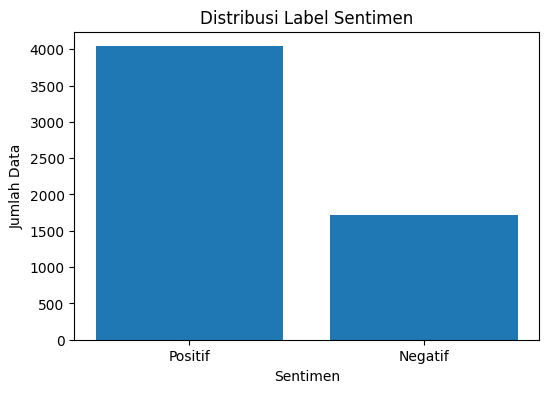

In [ ]:
import matplotlib.pyplot as plt

jumlah = df["label"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(jumlah.index, jumlah.values)

plt.title("Distribusi Label Sentimen")

plt.xlabel("Sentimen")

plt.ylabel("Jumlah Data")

plt.show()

In [ ]:
df.to_excel(
    "dataset_labeling.xlsx",
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


In [ ]:
display(df[[
    "content",
    "score",
    "label"
]].head(15))

,content,score,label
0,"aplikasi sering ngebag, logout sendiri,aplikas...",1,Negatif
1,Mantul,5,Positif
2,Mau login dipersulit. Masa tiba-tiba akun diba...,1,Negatif
3,"terimakasih, sangat membantu saya untuk membuk...",5,Positif
4,top,5,Positif
5,sangat bermanfaat👍🏻,5,Positif
6,aplikasi ini memang bagus,5,Positif
7,Aplikasi yg sangat bagus dan sangat membantu d...,5,Positif
8,ga bisa login akun di verifikasi mulu,1,Negatif
9,aplikasi kebanyakan erornya,1,Negatif


Split data

In [ ]:
from sklearn.model_selection import train_test_split

# Fitur (teks hasil preprocessing)
X = df["preprocessing"]

# Label sentimen
y = df["label"]

# Membagi data 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("DISTRIBUSI LABEL DATA TRAINING")
print("========================================")
print(y_train.value_counts())

print("\n========================================")
print("DISTRIBUSI LABEL DATA TESTING")
print("========================================")
print(y_test.value_counts())


DISTRIBUSI LABEL DATA TRAINING
label
Positif    3231
Negatif    1373
Name: count, dtype: int64

DISTRIBUSI LABEL DATA TESTING
label
Positif    808
Negatif    344
Name: count, dtype: int64


In [ ]:
train_df = pd.DataFrame({
    "preprocessing": X_train,
    "label": y_train
})

test_df = pd.DataFrame({
    "preprocessing": X_test,
    "label": y_test
})

print("\nData Training")
display(train_df.head())

print("\nData Testing")
display(test_df.head())


Data Training


,preprocessing,label
718,apk gajelas eror nya,Negatif
432,apk ribet tolol gagal login blokir akun banyak...,Negatif
5079,ok bagus rekomen banget bantu,Positif
2783,blum dapet kerja,Negatif
754,apk baik kali akun tau sebab,Negatif



Data Testing


,preprocessing,label
3826,good luck,Positif
2150,aplikasi nya susah masuk email,Negatif
3461,ok banget suka latih gratis nya ngasih sertifikat,Positif
2390,lowong kerja yg diposting gk yg smua sampe kia...,Negatif
185,tiga kali bikin akun gara masuk hasil masuk ak...,Negatif


In [ ]:
train_df.to_excel("data_training.xlsx", index=False)
test_df.to_excel("data_testing.xlsx", index=False)

print("Data training dan testing berhasil disimpan.")

Data training dan testing berhasil disimpan.


**tf** Idf

In [ ]:
# ============================================================
# 3.5 TF-IDF
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Membuat objek TF-IDF
tfidf = TfidfVectorizer()

# Training
X_train_tfidf = tfidf.fit_transform(X_train)

# Testing
X_test_tfidf = tfidf.transform(X_test)

print("========================================")
print("HASIL TF-IDF")
print("========================================")

print("Jumlah Data Training :", X_train_tfidf.shape[0])
print("Jumlah Data Testing  :", X_test_tfidf.shape[0])
print("Jumlah Fitur TF-IDF  :", X_train_tfidf.shape[1])

HASIL TF-IDF
Jumlah Data Training : 4604
Jumlah Data Testing  : 1152
Jumlah Fitur TF-IDF  : 3577


In [ ]:
feature_names = tfidf.get_feature_names_out()

print("Jumlah Vocabulary :", len(feature_names))

Jumlah Vocabulary : 3577


In [ ]:
print(X_train_tfidf.shape)

(4604, 3577)


In [ ]:
feature_names[:20]

array(['aada', 'aahh', 'aamiiiin', 'aamiin', 'aamiinn', 'aamiinnnn',
       'abad', 'abai', 'abal', 'abdul', 'abis', 'able', 'acc', 'access',
       'account', 'accounts', 'accurate', 'accurately', 'acount',
       'action'], dtype=object)

In [ ]:
tfidf_test = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

display(tfidf_test.head())

,aada,aahh,aamiiiin,aamiin,aamiinn,aamiinnnn,abad,abai,abal,abdul,...,youtube,yt,yth,ytta,yuk,zacky,zaini,zariah,zero,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
bobot_series = pd.Series(X_train_tfidf.sum(axis=0).A1, index=tfidf.get_feature_names_out())
bobot = bobot_series.sort_values(ascending=False)

bobot_tertinggi = pd.DataFrame({
    'Kata': bobot.index,
    'Bobot_TFIDF': bobot.values
})

print("=====  TOTAL BOBOT TF-IDF TERTINGGI ====")
display(bobot_tertinggi.head())

=====  TOTAL BOBOT TF-IDF TERTINGGI ====


,Kata,Bobot_TFIDF
0,bagus,378.982049
1,bantu,373.125334
2,good,217.693227
3,kerja,210.037263
4,ok,208.064306


In [ ]:
bobot_series = pd.Series(X_train_tfidf.sum(axis=0).A1, index=tfidf.get_feature_names_out())
bobot = bobot_series.sort_values(ascending=True)

bobot_tertinggi = pd.DataFrame({
    'Kata': bobot.index,
    'Bobot_TFIDF': bobot.values
})

print("===== TOTAL BOBOT TF-IDF TERENDAH ====")
display(bobot_tertinggi.head())

===== TOTAL BOBOT TF-IDF TERENDAH ====


,Kata,Bobot_TFIDF
0,accurately,0.072395
1,continues,0.072395
2,capabilities,0.072395
3,structure,0.072395
4,output,0.072395


In [ ]:
import numpy as np

mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

ranking = pd.DataFrame({
    "Kata": tfidf.get_feature_names_out(),
    "Bobot TF-IDF": mean_tfidf
})

ranking = ranking.sort_values(
    by="Bobot TF-IDF",
    ascending=False
)

display(ranking.head(10))

,Kata,Bobot TF-IDF
274,bagus,0.082316
313,bantu,0.081044
1121,good,0.047283
1603,kerja,0.045621
2345,ok,0.045192
1960,mantap,0.043849
191,aplikasi,0.035622
570,cari,0.033374
2134,mudah,0.023424
1854,login,0.018815


In [ ]:
display(ranking.tail(10))

,Kata,Bobot TF-IDF
837,documents,0.000016
1268,humanoid,0.000016
346,become,0.000016
224,asi,0.000016
3077,structure,0.000016
647,continues,0.000016
1269,humans,0.000016
173,anything,0.000016
2401,output,0.000016
138,analyze,0.000016


In [ ]:
tfidf_train = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)
tfidf_train.to_excel("TFIDF_Training.xlsx", index=False)
tfidf_test.to_excel("TFIDF_Testing.xlsx", index=False)

print("TF-IDF berhasil disimpan")

TF-IDF berhasil disimpan


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

K-fold/10 cross Validation

In [ ]:
# ============================================================
# 3.6 K-FOLD CROSS VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold

# Membuat objek Stratified K-Fold
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

print("========================================")
print("K-FOLD CROSS VALIDATION")
print("========================================")

print("Jumlah Fold :", skf.get_n_splits())

K-FOLD CROSS VALIDATION
Jumlah Fold : 10


In [ ]:
fold = 1

for train_index, test_index in skf.split(X_train_tfidf, y_train):

    print("="*40)
    print(f"Fold {fold}")
    print("="*40)

    print("Data Training :", len(train_index))
    print("Data Testing  :", len(test_index))

    fold += 1

Fold 1
Data Training : 4143
Data Testing  : 461
Fold 2
Data Training : 4143
Data Testing  : 461
Fold 3
Data Training : 4143
Data Testing  : 461
Fold 4
Data Training : 4143
Data Testing  : 461
Fold 5
Data Training : 4144
Data Testing  : 460
Fold 6
Data Training : 4144
Data Testing  : 460
Fold 7
Data Training : 4144
Data Testing  : 460
Fold 8
Data Training : 4144
Data Testing  : 460
Fold 9
Data Training : 4144
Data Testing  : 460
Fold 10
Data Training : 4144
Data Testing  : 460


In [ ]:
# ============================================================
# K-FOLD NAÏVE BAYES
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

cv_nb = cross_val_score(
    nb_model,
    X_train_tfidf,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("========================================")
print("HASIL K-FOLD NAÏVE BAYES")
print("========================================")

for i, score in enumerate(cv_nb, start=1):
    print(f"Fold {i} : {score:.4f}")

print("\nRata-rata Accuracy :", cv_nb.mean())
print("Standar Deviasi    :", cv_nb.std())

HASIL K-FOLD NAÏVE BAYES
Fold 1 : 0.9024
Fold 2 : 0.9306
Fold 3 : 0.8959
Fold 4 : 0.9046
Fold 5 : 0.8935
Fold 6 : 0.8804
Fold 7 : 0.8870
Fold 8 : 0.9130
Fold 9 : 0.9130
Fold 10 : 0.9022

Rata-rata Accuracy : 0.9022536074695842
Standar Deviasi    : 0.013669605864101774


In [ ]:
# ============================================================
# K-FOLD SVM
# ============================================================

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

cv_svm = cross_val_score(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("========================================")
print("HASIL K-FOLD SVM")
print("========================================")

for i, score in enumerate(cv_svm, start=1):
    print(f"Fold {i} : {score:.4f}")

print("\nRata-rata Accuracy :", cv_svm.mean())
print("Standar Deviasi    :", cv_svm.std())

HASIL K-FOLD SVM
Fold 1 : 0.8872
Fold 2 : 0.9328
Fold 3 : 0.8764
Fold 4 : 0.9002
Fold 5 : 0.8913
Fold 6 : 0.8891
Fold 7 : 0.8848
Fold 8 : 0.9109
Fold 9 : 0.8957
Fold 10 : 0.9043

Rata-rata Accuracy : 0.8972616240686598
Standar Deviasi    : 0.015172586770642775


In [ ]:
import pandas as pd

hasil_kfold = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, 11)],
    "Naïve Bayes": cv_nb,
    "SVM": cv_svm
})

display(hasil_kfold)

,Fold,Naïve Bayes,SVM
0,Fold 1,0.902386,0.887202
1,Fold 2,0.930586,0.932755
2,Fold 3,0.895879,0.876356
3,Fold 4,0.904555,0.900217
4,Fold 5,0.893478,0.891304
5,Fold 6,0.880435,0.889130
6,Fold 7,0.886957,0.884783
7,Fold 8,0.913043,0.910870
8,Fold 9,0.913043,0.895652
9,Fold 10,0.902174,0.904348


In [ ]:
print("========================================")
print("RATA-RATA HASIL K-FOLD")
print("========================================")

print(f"Naïve Bayes : {cv_nb.mean():.4f}")
print(f"SVM         : {cv_svm.mean():.4f}")

RATA-RATA HASIL K-FOLD
Naïve Bayes : 0.9023
SVM         : 0.8973


Pelatihan Model Naïve Bayes

In [ ]:
# ============================================================
# 3.7 PELATIHAN MODEL NAÏVE BAYES
# ============================================================

from sklearn.naive_bayes import MultinomialNB

# Membuat model Naïve Bayes
nb_model = MultinomialNB()

# Melatih model menggunakan data training
nb_model.fit(X_train_tfidf, y_train)

print("========================================")
print("PELATIHAN MODEL NAÏVE BAYES BERHASIL")
print("========================================")

print("Jumlah Data Training :", X_train_tfidf.shape[0])
print("Jumlah Data Testing  :", X_test_tfidf.shape[0])
print("Jumlah Fitur TF-IDF  :", X_train_tfidf.shape[1])

print("\nModel Naïve Bayes berhasil dilatih menggunakan data training.")

PELATIHAN MODEL NAÏVE BAYES BERHASIL
Jumlah Data Training : 4604
Jumlah Data Testing  : 1152
Jumlah Fitur TF-IDF  : 3577

Model Naïve Bayes berhasil dilatih menggunakan data training.


In [ ]:
# ============================================================
# PREDIKSI DATA TESTING
# ============================================================

# Melakukan prediksi pada data testing
y_pred_nb = nb_model.predict(X_test_tfidf)

print("========================================")
print("PREDIKSI DATA TESTING")
print("========================================")

print("Jumlah Data Testing :", len(y_pred_nb))

# Menampilkan beberapa hasil prediksi
hasil_prediksi = pd.DataFrame({
    "Label Aktual": y_test.values,
    "Label Prediksi": y_pred_nb
})

display(hasil_prediksi.head(10))

PREDIKSI DATA TESTING
Jumlah Data Testing : 1152


,Label Aktual,Label Prediksi
0,Positif,Positif
1,Negatif,Negatif
2,Positif,Positif
3,Negatif,Positif
4,Negatif,Negatif
5,Negatif,Negatif
6,Positif,Positif
7,Positif,Positif
8,Negatif,Positif
9,Positif,Positif


HASIL EVALUASI MODEL NAÏVE BAYES
Accuracy  : 0.8967
Precision : 0.8962
Recall    : 0.8967
F1-Score  : 0.8939

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Negatif       0.89      0.75      0.81       344
     Positif       0.90      0.96      0.93       808

    accuracy                           0.90      1152
   macro avg       0.89      0.85      0.87      1152
weighted avg       0.90      0.90      0.89      1152


CONFUSION MATRIX
[[257  87]
 [ 32 776]]

NILAI TP TN FP FN
True Positive (TP) : 776
True Negative (TN) : 257
False Positive (FP): 87
False Negative (FN): 32


,Komponen,Jumlah
0,True Positive (TP),776
1,True Negative (TN),257
2,False Positive (FP),87
3,False Negative (FN),32


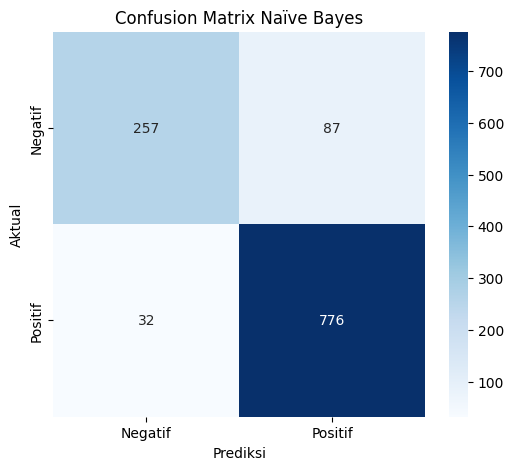

In [ ]:
# ============================================================
# 3.8 EVALUASI MODEL NAÏVE BAYES
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# MENGHITUNG METRIK EVALUASI
# ============================================================

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='weighted')
recall = recall_score(y_test, y_pred_nb, average='weighted')
f1 = f1_score(y_test, y_pred_nb, average='weighted')

print("====================================")
print("HASIL EVALUASI MODEL NAÏVE BAYES")
print("====================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(classification_report(y_test, y_pred_nb))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_nb)

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")
print(cm)

# ============================================================
# TP TN FP FN
# ============================================================

tn, fp, fn, tp = cm.ravel()

print("\n====================================")
print("NILAI TP TN FP FN")
print("====================================")

print("True Positive (TP) :", tp)
print("True Negative (TN) :", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)

# ============================================================
# TABEL TP TN FP FN
# ============================================================

hasil_cm = pd.DataFrame({
    "Komponen": [
        "True Positive (TP)",
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)"
    ],
    "Jumlah": [tp, tn, fp, fn]
})

display(hasil_cm)

# ============================================================
# VISUALISASI CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif', 'Positif'],
    yticklabels=['Negatif', 'Positif']
)

plt.title("Confusion Matrix Naïve Bayes")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

Pelatihan Model Support Vector Machine (SVM)

In [ ]:
# ============================================================
# 3.9 PELATIHAN MODEL SUPPORT VECTOR MACHINE (SVM)
# ============================================================

from sklearn.svm import LinearSVC

# Membuat model SVM
svm_model = LinearSVC(
    random_state=42
)

# Melatih model menggunakan data training
svm_model.fit(X_train_tfidf, y_train)

print("========================================")
print("PELATIHAN MODEL SUPPORT VECTOR MACHINE")
print("========================================")

print("Jumlah Data Training :", X_train_tfidf.shape[0])
print("Jumlah Data Testing  :", X_test_tfidf.shape[0])
print("Jumlah Fitur TF-IDF  :", X_train_tfidf.shape[1])

print("\nModel SVM berhasil dilatih menggunakan data training.")

PELATIHAN MODEL SUPPORT VECTOR MACHINE
Jumlah Data Training : 4604
Jumlah Data Testing  : 1152
Jumlah Fitur TF-IDF  : 3577

Model SVM berhasil dilatih menggunakan data training.


In [ ]:
# ============================================================
# PREDIKSI MODEL SVM
# ============================================================

# Melakukan prediksi pada data testing
y_pred_svm = svm_model.predict(X_test_tfidf)

print("========================================")
print("PREDIKSI MODEL SVM")
print("========================================")

print("Jumlah Data Testing :", len(y_pred_svm))

# Menampilkan beberapa hasil prediksi
hasil_prediksi_svm = pd.DataFrame({
    "Label Aktual": y_test.values,
    "Label Prediksi": y_pred_svm
})

display(hasil_prediksi_svm.head(10))

PREDIKSI MODEL SVM
Jumlah Data Testing : 1152


,Label Aktual,Label Prediksi
0,Positif,Positif
1,Negatif,Negatif
2,Positif,Positif
3,Negatif,Positif
4,Negatif,Negatif
5,Negatif,Negatif
6,Positif,Positif
7,Positif,Positif
8,Negatif,Positif
9,Positif,Positif


HASIL EVALUASI MODEL SVM
Accuracy  : 0.8984
Precision : 0.8971
Recall    : 0.8984
F1-Score  : 0.8972

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Negatif       0.86      0.79      0.82       344
     Positif       0.91      0.94      0.93       808

    accuracy                           0.90      1152
   macro avg       0.89      0.87      0.88      1152
weighted avg       0.90      0.90      0.90      1152


CONFUSION MATRIX
[[272  72]
 [ 45 763]]

HASIL TP TN FP FN
True Positive (TP) : 763
True Negative (TN) : 272
False Positive (FP): 72
False Negative (FN): 45


,Komponen,Jumlah
0,True Positive (TP),763
1,True Negative (TN),272
2,False Positive (FP),72
3,False Negative (FN),45


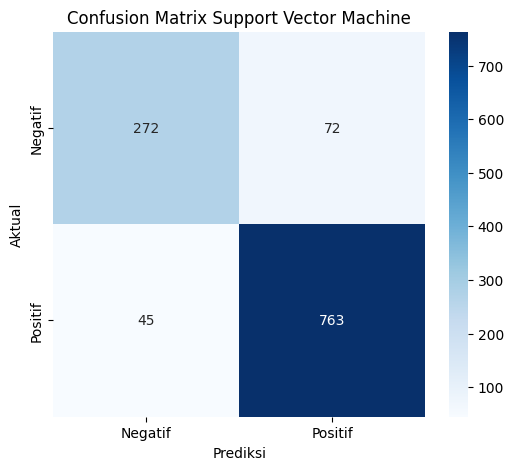

In [ ]:
# ============================================================
# 3.10 EVALUASI MODEL SUPPORT VECTOR MACHINE (SVM)
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# MENGHITUNG METRIK EVALUASI
# ============================================================

accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm, average='weighted')
recall = recall_score(y_test, y_pred_svm, average='weighted')
f1 = f1_score(y_test, y_pred_svm, average='weighted')

print("====================================")
print("HASIL EVALUASI MODEL SVM")
print("====================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(classification_report(y_test, y_pred_svm))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred_svm)

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")
print(cm)

# ============================================================
# TP TN FP FN
# ============================================================

tn, fp, fn, tp = cm.ravel()

print("\n====================================")
print("HASIL TP TN FP FN")
print("====================================")

print("True Positive (TP) :", tp)
print("True Negative (TN) :", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)

# ============================================================
# TABEL TP TN FP FN
# ============================================================

hasil_cm = pd.DataFrame({
    'Komponen': [
        'True Positive (TP)',
        'True Negative (TN)',
        'False Positive (FP)',
        'False Negative (FN)'
    ],
    'Jumlah': [tp, tn, fp, fn]
})

display(hasil_cm)

# ============================================================
# VISUALISASI CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif','Positif'],
    yticklabels=['Negatif','Positif']
)

plt.title("Confusion Matrix Support Vector Machine")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()



Perbandingan Kedua Model


In [ ]:
# ============================================================
# 3.11 PERBANDINGAN HASIL NAÏVE BAYES DAN SVM
# ============================================================

hasil_perbandingan = pd.DataFrame({
    'Model': ['Naïve Bayes', 'Support Vector Machine'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

print("========================================")
print("PERBANDINGAN HASIL MODEL")
print("========================================")

display(hasil_perbandingan)

PERBANDINGAN HASIL MODEL


,Model,Accuracy,Precision,Recall,F1-Score
0,Naïve Bayes,0.896701,0.896228,0.896701,0.893914
1,Support Vector Machine,0.898438,0.897131,0.898438,0.897198


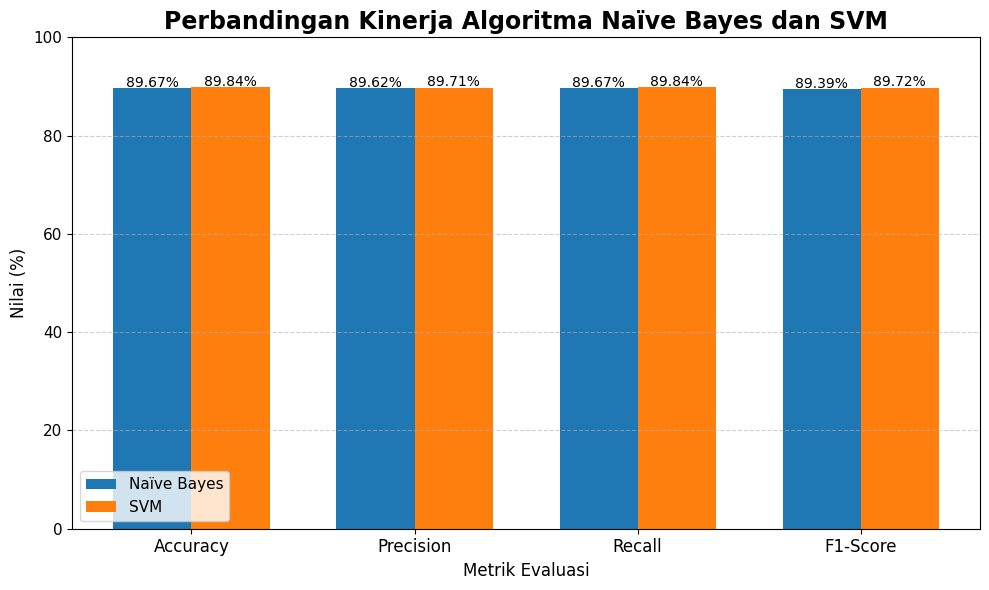

In [ ]:
# ============================================================
# GRAFIK PERBANDINGAN KINERJA NAÏVE BAYES DAN SVM
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Mengambil nilai dari DataFrame
nb = hasil_perbandingan.iloc[0, 1:] * 100
svm = hasil_perbandingan.iloc[1, 1:] * 100

metrik = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metrik))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(
    x - width/2,
    nb,
    width,
    label='Naïve Bayes'
)

bars2 = plt.bar(
    x + width/2,
    svm,
    width,
    label='SVM'
)

# Menampilkan nilai di atas batang
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center',
        fontsize=10
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.2f}%',
        ha='center',
        fontsize=10
    )

plt.xticks(x, metrik, fontsize=12)
plt.yticks(fontsize=11)

plt.ylabel("Nilai (%)", fontsize=12)
plt.xlabel("Metrik Evaluasi", fontsize=12)

plt.title(
    "Perbandingan Kinerja Algoritma Naïve Bayes dan SVM",
    fontsize=17,
    fontweight='bold'
)

plt.ylim(0,100)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()

word cloud

In [ ]:
!pip install wordcloud

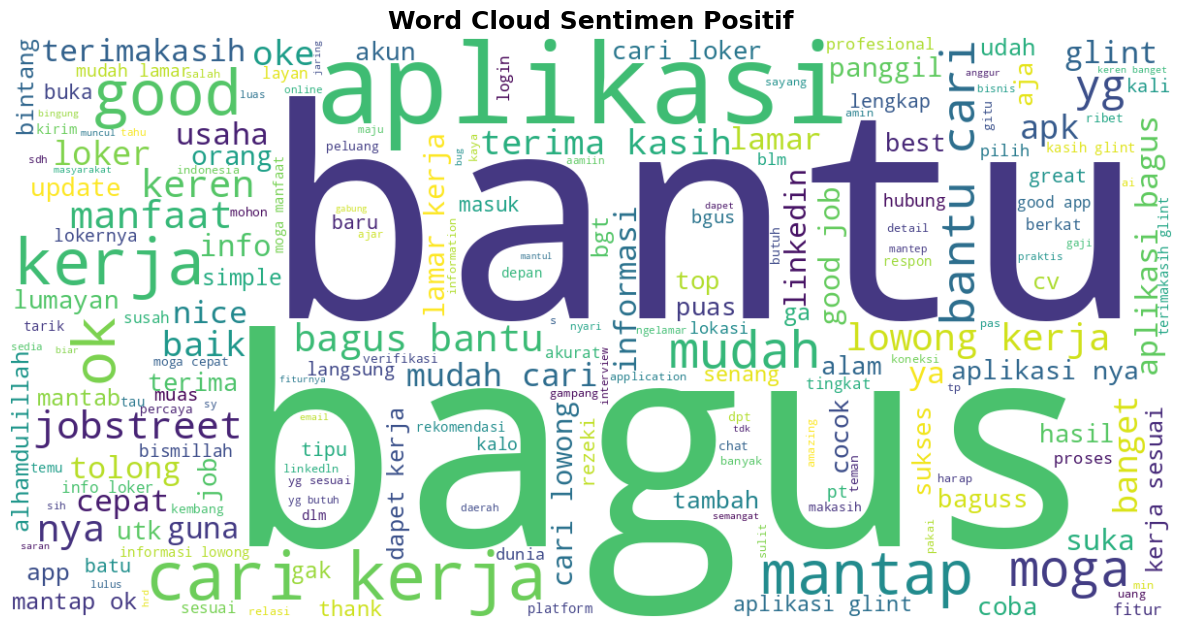

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ============================================================
# WORD CLOUD SENTIMEN POSITIF
# ============================================================

text_pos = " ".join(
    df[df['label'] == 'Positif']['preprocessing'].astype(str)
)

wordcloud_pos = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200
).generate(text_pos)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Positif", fontsize=18, fontweight='bold')
plt.show()

In [ ]:
from collections import Counter
import pandas as pd

# Ambil data berlabel positif
df_positif = df[df["label"] == "Positif"]

# Gabungkan seluruh teks
teks_positif = " ".join(df_positif["preprocessing"])

# Hitung frekuensi setiap kata
counter = Counter(teks_positif.split())

# Total seluruh kata positif
total_kata = sum(counter.values())

# Buat DataFrame
df_top10_positif = pd.DataFrame(
    counter.most_common(10),
    columns=["Kata", "Frekuensi"]
)


# Tambahkan nomor urut
df_top10_positif.index += 1
df_top10_positif.index.name = "No"

# Tampilkan tabel
display(df_top10_positif)

,Kata,Frekuensi
No,,
1,kerja,808
2,bantu,785
3,bagus,682
4,cari,467
5,aplikasi,454
6,good,333
7,mudah,284
8,mantap,275
9,ok,267


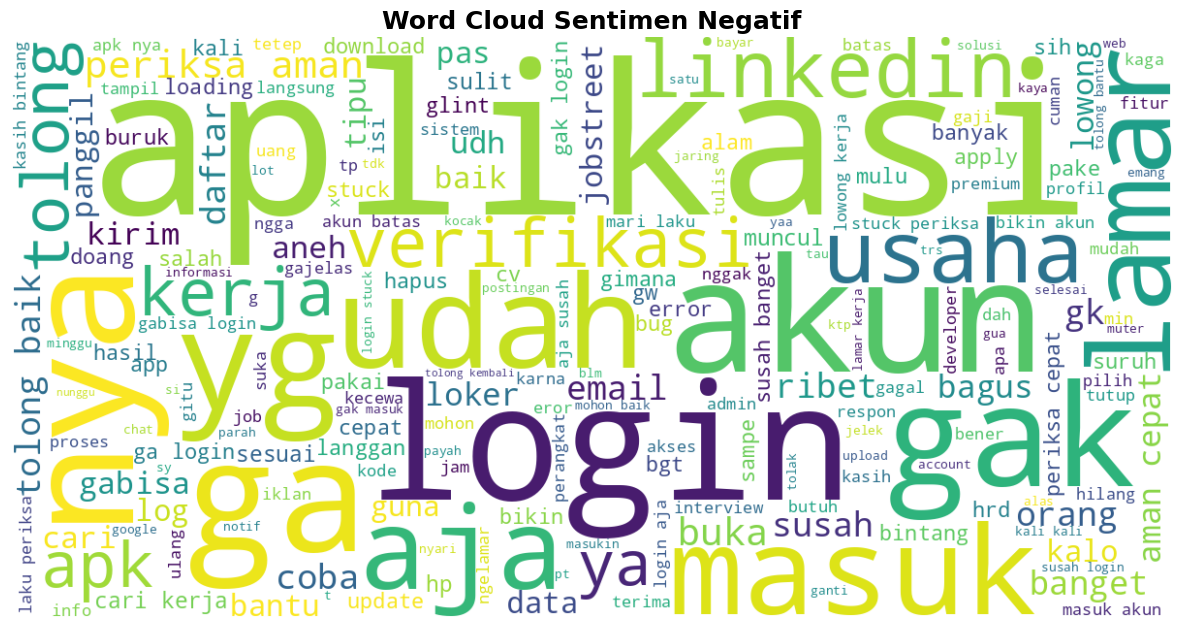

In [ ]:
# ============================================================
# WORD CLOUD SENTIMEN NEGATIF
# ============================================================

text_neg = " ".join(
    df[df['label'] == 'Negatif']['preprocessing'].astype(str)
)

wordcloud_neg = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200
).generate(text_neg)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud Sentimen Negatif", fontsize=18, fontweight='bold')
plt.show()

In [ ]:
from collections import Counter
import pandas as pd

# Ambil hanya data negatif
df_negatif = df[df["label"] == "Negatif"]

# Gabungkan seluruh teks
teks_negatif = " ".join(df_negatif["preprocessing"])

# Hitung frekuensi kata
counter = Counter(teks_negatif.split())

# Buat DataFrame
df_frekuensi_negatif = pd.DataFrame(
    counter.items(),
    columns=["Kata", "Frekuensi"]
)

# Urutkan dari frekuensi terbesar
df_frekuensi_negatif = df_frekuensi_negatif.sort_values(
    by="Frekuensi",
    ascending=False
).reset_index(drop=True)

# Tambahkan nomor
df_frekuensi_negatif.index += 1
df_frekuensi_negatif.index.name = "No"

# Tampilkan 20 kata teratas
display(df_frekuensi_negatif.head(10))

,Kata,Frekuensi
No,,
1,aplikasi,491
2,login,413
3,akun,338
4,ga,264
5,gak,236
6,nya,235
7,kerja,214
8,tolong,207
9,masuk,193


Menghitung hasil sentimen setiap aplikasi

In [ ]:
# Menghitung jumlah sentimen positif setiap aplikasi

hasil_positif = (
    df[df["label"] == "Positif"]
    .groupby("app")
    .size()
    .reset_index(name="jumlah_positif")
)

display(hasil_positif)

,app,jumlah_positif
0,Glints,1665
1,JobStreet,1448
2,LinkedIn,926


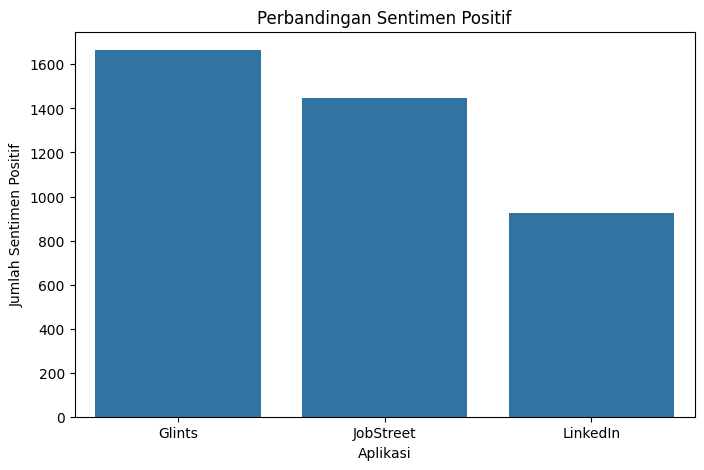

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x='app',
    y='jumlah_positif',
    data=hasil_positif
)

plt.title('Perbandingan Sentimen Positif')
plt.xlabel('Aplikasi')
plt.ylabel('Jumlah Sentimen Positif')

plt.show()

In [ ]:
hasil_negatif = df[df["label"] == "Negatif"].groupby("app").size().reset_index(name="jumlah_negatif")

display(hasil_negatif)

,app,jumlah_negatif
0,Glints,240
1,JobStreet,448
2,LinkedIn,1029


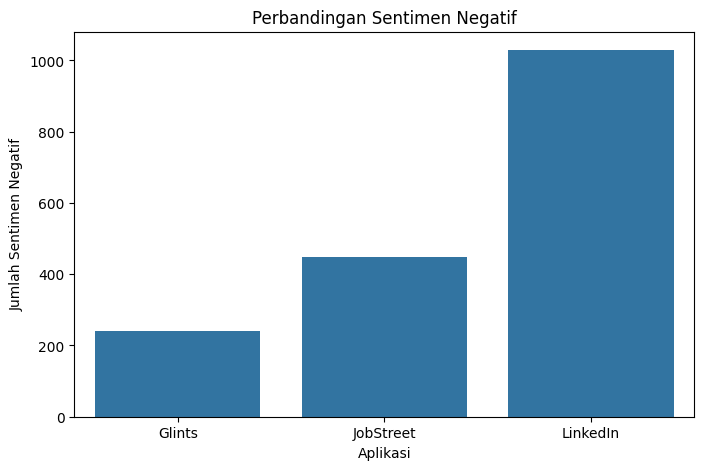

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=hasil_negatif,
    x="app",
    y="jumlah_negatif"
)

plt.title("Perbandingan Sentimen Negatif")
plt.xlabel("Aplikasi")
plt.ylabel("Jumlah Sentimen Negatif")

plt.show()